In [ ]:
import glob
import tqdm

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.patches import Patch

from utils import *

BASE_PATH = '../Paper-IS26-experiments/'

In [ ]:
aligns = []
for aligns_path in tqdm.tqdm(glob.glob(f'{BASE_PATH}/**/aligns.pkl', recursive=True)):
    df = pd.read_pickle(aligns_path)
    experiment_config = read_config_from_path(aligns_path, BASE_PATH)
    for column, value in experiment_config.items():
        df[column] = value
    aligns.append(df)

if len(aligns) == 0:
    raise Warning(f"No aligns found in the specified path: {BASE_PATH}")

aligns = pd.concat(aligns)
aligns = aligns.reset_index(drop=True)
aligns = aligns[aligns.dataset == 'spanishad']

  0%|          | 0/97 [00:00<?, ?it/s]

100%|██████████| 97/97 [00:00<00:00, 913.83it/s]


In [ ]:
aligners = aligns['aligner'].str.replace('-non_speech', '').str.split('-postprocess-').str[0]
root_common_tokens = get_common_tokens_with_root(list(aligners.unique()))
aligns['aligner_name'] = aligners.map(lambda name: compute_short_name_with_root(name, root_common_tokens))

postprocess_aligner = aligns['aligner'].apply(lambda x: x.split('-postprocess-')[1] if '-postprocess-' in x else None)
aligns['postprocess_aligner_name'] = postprocess_aligner.map(lambda name: compute_short_name_with_root(name, root_common_tokens) if pd.notna(name) else None)
aligns['short_aligner'] = aligns.apply(lambda row: row['aligner_name'] if pd.isna(row['postprocess_aligner_name']) else f"{row['aligner_name']}\n+\n{row['postprocess_aligner_name']}", axis=1)
aligns['intervals_condition'] = aligns['aligner'].apply(lambda x: 'non_speech' if 'non_speech' in x else 'full_audio' if 'full_audio' in x else 'only_speech')  

aligns['interval_duration'] = aligns['end'] - aligns['start']

In [ ]:
audio_durations = aligns[(aligns['aligner'] == 'full_audio') & (aligns['subset'] == 'original')].groupby('sample_id').first()['interval_duration'].reset_index().set_index('sample_id')
audio_durations.head()

,interval_duration
sample_id,
AD_05_lamina_1,91.32
AD_07_lamina_1,117.44
AD_10_lamina_1,114.11
AD_11_lamina_1,137.30
AD_12_lamina_1,164.87


In [ ]:
# dataset_samples = {}
# for (dataset, subset), dataset_df in aligns.groupby(['dataset', 'subset']):
#     dataset_samples[(dataset, subset)] = dataset_df.sample_id
# 
# to_remove = []
# print("Checking for aligners with a different number of unique samples than expected...")
# print('########')
# for (dataset, subset, aligner, condition), group_df in aligns.groupby(['dataset', 'subset', 'short_aligner', 'intervals_condition']):
#     if group_df.sample_id.nunique() != dataset_samples[(dataset, subset)].nunique():
#         aligner_name = aligner.replace('\n', ' ')
#         print(f"DATASET={dataset} - {subset}\nALIGNER={aligner_name}\nCONDITION={condition}\nNumber of unique samples is {group_df.sample_id.nunique()} (expected {dataset_samples[(dataset, subset)].nunique()})")
#         print("Missing samples:", set(dataset_samples[(dataset, subset)].unique()) - set(group_df.sample_id.unique()))
#         print('########')
#         to_remove.extend(group_df.index)
# aligns = aligns.drop(index=to_remove)
# print(f"Removed {len(to_remove)} rows from the analysis.")


Checking for aligners with a different number of unique samples than expected...
########
Removed 0 rows from the analysis.


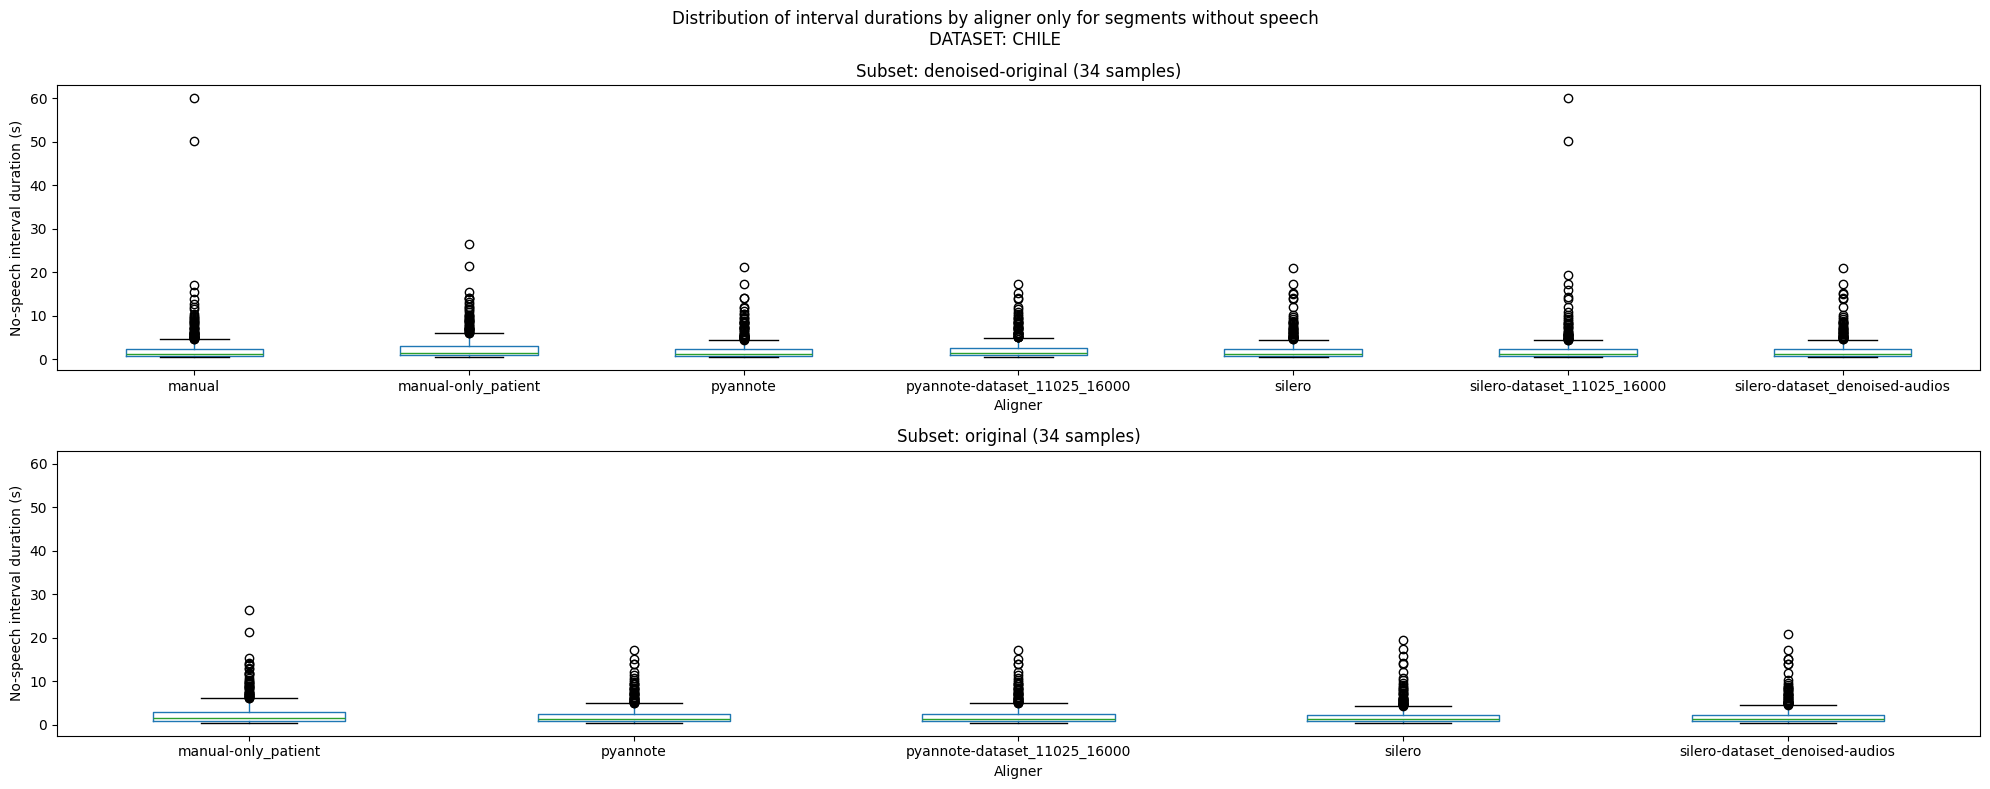

In [117]:
for dataset, dataset_df in aligns.groupby('dataset'):
    fig, axes = plt.subplots(figsize=(20, 4 * len(dataset_df.subset.unique())), nrows=len(dataset_df.subset.unique()), ncols=1, sharey=True)
    if len(dataset_df.subset.unique()) == 1: axes = [axes]    
    only_non_speech_intervals = dataset_df[dataset_df.intervals_condition == 'non_speech'].copy()
    for ax, (subset, subset_df) in zip(axes, only_non_speech_intervals.groupby('subset')):
        subset_df.boxplot(column='interval_duration', by='short_aligner', ax=ax, grid=False)
        ax.set_title(f'Subset: {subset} ({subset_df.sample_id.nunique()} samples)')
        ax.set_ylabel('No-speech interval duration (s)')
        ax.set_xlabel('Aligner')
    plt.suptitle(f'Distribution of interval durations by aligner only for segments without speech\nDATASET: {dataset.upper()}')
    plt.tight_layout()
    plt.show()

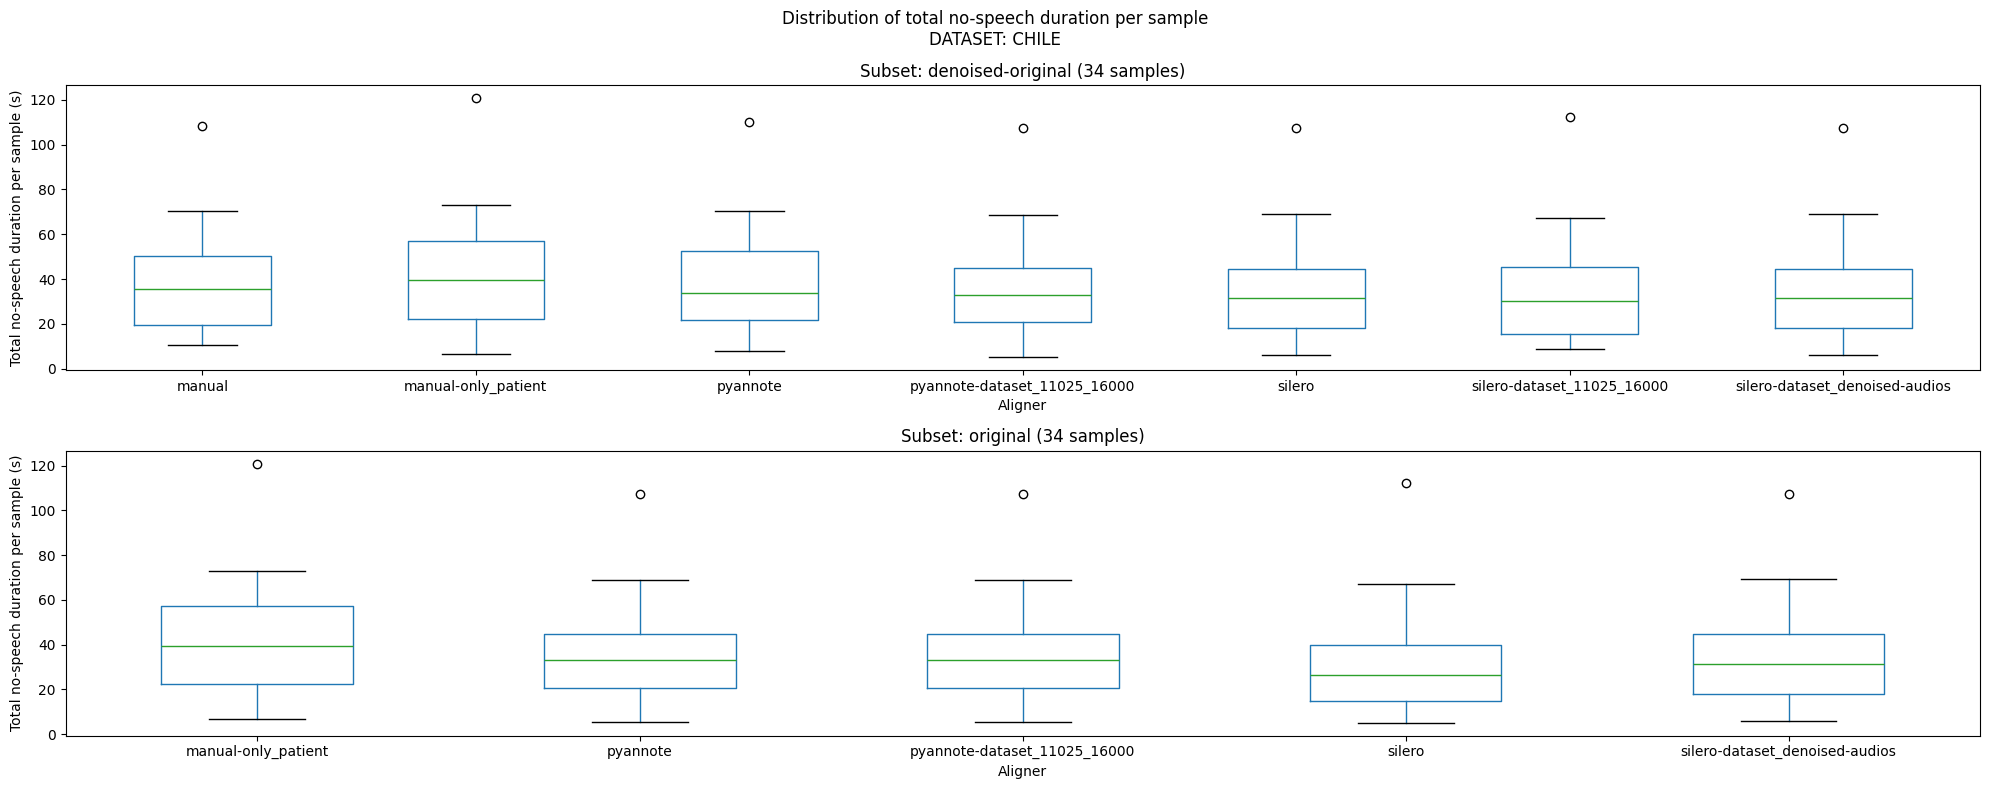

In [96]:
for dataset, dataset_df in aligns.groupby('dataset'):
    fig, axes = plt.subplots(figsize=(20, 4 * len(dataset_df.subset.unique())), nrows=len(dataset_df.subset.unique()), ncols=1, sharey=True)
    if len(dataset_df.subset.unique()) == 1: axes = [axes]
    only_non_speech_intervals = dataset_df[dataset_df.intervals_condition == 'non_speech'].copy()
    for ax, (subset, subset_df) in zip(axes, only_non_speech_intervals.groupby('subset')):
        subset_df.groupby(['short_aligner', 'sample_id'])['interval_duration'].sum().reset_index().boxplot(column='interval_duration', by='short_aligner', ax=ax, grid=False)
        ax.set_title(f'Subset: {subset} ({subset_df.sample_id.nunique()} samples)')
        ax.set_ylabel('Total no-speech duration per sample (s)')
        ax.set_xlabel('Aligner')
    plt.suptitle(f'Distribution of total no-speech duration per sample\nDATASET: {dataset.upper()}')
    plt.tight_layout()
    plt.show()

In [97]:
only_non_speech_intervals = aligns[aligns.intervals_condition == 'non_speech'].copy()
only_non_speech_intervals = only_non_speech_intervals.groupby(['dataset', 'subset', 'short_aligner', 'sample_id'])['interval_duration'].sum().reset_index()
only_non_speech_intervals.groupby(['dataset', 'subset', 'short_aligner'])['interval_duration'].describe()

count       mean  \
dataset subset            short_aligner                                      
chile   denoised-original manual                           34.0  38.165294   
                          manual-only_patient              34.0  41.335882   
                          pyannote                         34.0  38.669412   
                          pyannote-dataset_11025_16000     34.0  36.025588   
                          silero                           34.0  33.869118   
                          silero-dataset_11025_16000       34.0  33.492353   
                          silero-dataset_denoised-audios   34.0  33.869118   
        original          manual-only_patient              34.0  41.335882   
                          pyannote                         34.0  36.025588   
                          pyannote-dataset_11025_16000     34.0  36.025588   
                          silero                           34.0  30.926765   
                          silero-dataset_denoised-audios   34.0  33.869118   

                                                                std    min  \
dataset subset            short_aligner                                      
chile   denoised-original manual                          21.115955  10.60   
                          manual-only_patient             23.696684   6.63   
                          pyannote                        21.910853   7.95   
                          pyannote-dataset_11025_16000    20.529010   5.20   
                          silero                          21.600982   5.85   
                          silero-dataset_11025_16000      21.731046   8.64   
                          silero-dataset_denoised-audios  21.600982   5.85   
        original          manual-only_patient             23.696684   6.63   
                          pyannote                        20.529010   5.20   
                          pyannote-dataset_11025_16000    20.529010   5.20   
                          silero                          21.622293   5.14   
                          silero-dataset_denoised-audios  21.600982   5.85   

                                                              25%     50%  \
dataset subset            short_aligner                                     
chile   denoised-original manual                          19.4375  35.580   
                          manual-only_patient             22.2725  39.430   
                          pyannote                        21.7125  33.845   
                          pyannote-dataset_11025_16000    20.8100  32.940   
                          silero                          18.0250  31.500   
                          silero-dataset_11025_16000      15.5675  30.345   
                          silero-dataset_denoised-audios  18.0250  31.500   
        original          manual-only_patient             22.2725  39.430   
                          pyannote                        20.8100  32.940   
                          pyannote-dataset_11025_16000    20.8100  32.940   
                          silero                          14.8325  26.360   
                          silero-dataset_denoised-audios  18.0250  31.500   

                                                              75%     max  
dataset subset            short_aligner                                    
chile   denoised-original manual                          50.1700  108.42  
                          manual-only_patient             57.1100  120.83  
                          pyannote                        52.3625  110.12  
                          pyannote-dataset_11025_16000    44.8000  107.26  
                          silero                          44.6200  107.46  
                          silero-dataset_11025_16000      45.1975  112.26  
                          silero-dataset_denoised-audios  44.6200  107.46  
        original          manual-only_patient             57.1100  120.83  
                          pyannot

In [ ]:
print('Available aligns names', aligns.short_aligner.unique())

manual_per_dataset = {
    'spanishad': 'manual-ipu'
}

print('Datasets with manual alignments for speech segments:', list(manual_per_dataset.keys()))

Available aligns names ['silero' 'pyannote' 'pyannote-dataset_11025_16000'
 'silero-dataset_denoised-audios' 'manual' 'silero-dataset_11025_16000'
 'manual-only_patient' 'whole_audio']
Datasets with manual alignments for speech segments: ['chile']


In [111]:
manual_name_for_speech_segments = manual_per_dataset[dataset]
manual_only_speech = aligns[(aligns.short_aligner == manual_name_for_speech_segments) & 
                            (aligns.intervals_condition != 'non_speech')].drop_duplicates(subset=['sample_id', 'start', 'end'], keep='first')
aligns.short_aligner.unique()

array(['silero', 'pyannote', 'pyannote-dataset_11025_16000',
       'silero-dataset_denoised-audios', 'manual',
       'silero-dataset_11025_16000', 'manual-only_patient', 'whole_audio'],
      dtype=object)

In [110]:
mismatch_percentages = []
for (dataset, subset), dataset_df in aligns.groupby(['dataset', 'subset']):
    if dataset not in manual_per_dataset.keys():
        continue
    
    manual_name_for_speech_segments = manual_per_dataset[dataset]
    manual_only_speech = aligns[(aligns.short_aligner == manual_name_for_speech_segments) & 
                                (aligns.intervals_condition != 'non_speech')].drop_duplicates(subset=['sample_id', 'start', 'end'], keep='first')
    for sample_id, sample_aligns in dataset_df.groupby('sample_id'):
        sample_ref_df = manual_only_speech[manual_only_speech.sample_id == sample_id]
        total_ref_duration = (sample_ref_df.end - sample_ref_df.start).sum()
        
        for i, (short_aligner, df_aligner) in enumerate(sample_aligns.groupby('short_aligner'), start=1):
            df_aligner = df_aligner[df_aligner.intervals_condition == 'non_speech']
            
            mismatch_duration = 0.0
            for _, sil_row in df_aligner.iterrows():
                for _, speech_row in sample_ref_df.iterrows():
                    start_inter = max(sil_row.start, speech_row.start)
                    end_inter = min(sil_row.end, speech_row.end)
                    if start_inter < end_inter:
                        mismatch_duration += end_inter - start_inter
            if total_ref_duration == 0:
                continue
                # print(f"Warning: Total reference duration is zero for sample_id {sample_id} in dataset {dataset} for aligner {short_aligner}. Skipping proportion calculation.")
                # raise ValueError(f"Total reference duration is zero for sample_id {sample_id} in dataset {dataset} for aligner {short_aligner}. Cannot calculate mismatch proportion.")
            proportion_missed_speech = (mismatch_duration / total_ref_duration) * 100

            non_speech_dur_ref = audio_durations.loc[sample_id]['interval_duration'] - total_ref_duration
            missing_non_speech = non_speech_dur_ref - df_aligner.interval_duration.sum()
            
            if proportion_missed_speech > 0:
                mismatch_percentages.append({
                    'dataset': dataset,
                    'subset': subset,
                    'sample_id': sample_id,
                    'short_aligner': short_aligner,
                    'proportion_speech_leakage': proportion_missed_speech,
                    'amount_missed_non_speech': missing_non_speech
                })
            if proportion_missed_speech < 0:
                print('Negative percentage detected:', sample_id, short_aligner, proportion_missed_speech)         
        
mismatch_percentages = pd.DataFrame(mismatch_percentages)
mismatch_percentages['label'] = mismatch_percentages['subset'] + '\n' + mismatch_percentages['short_aligner']
mismatch_percentages = mismatch_percentages.reset_index(drop=True)


KeyError: 'subset'

In [85]:
def plot_distribution(df, col, title):
    order = (df.groupby("label")[col].median().sort_values().index)
    plt.figure(figsize=(20, 6))

    sns.boxplot(data=df, x="label", y=col, order=order, color='lightblue', showfliers=False)
    sns.stripplot(data=df, x="label", y=col, order=order, alpha=0.8, size=3, color='grey', jitter=True)
    plt.xlabel("Subset + Aligner")

    ax = plt.gca()
    ax.axhline(0, color='red', linestyle='--', alpha=0.3)
    ax.axhline(10, color='red', linestyle='--', alpha=0.3)
    
    plt.title(title)
    plt.tight_layout()
    plt.show()
    

Speech leakage into non-speech segments (%) — summary (lower is better)


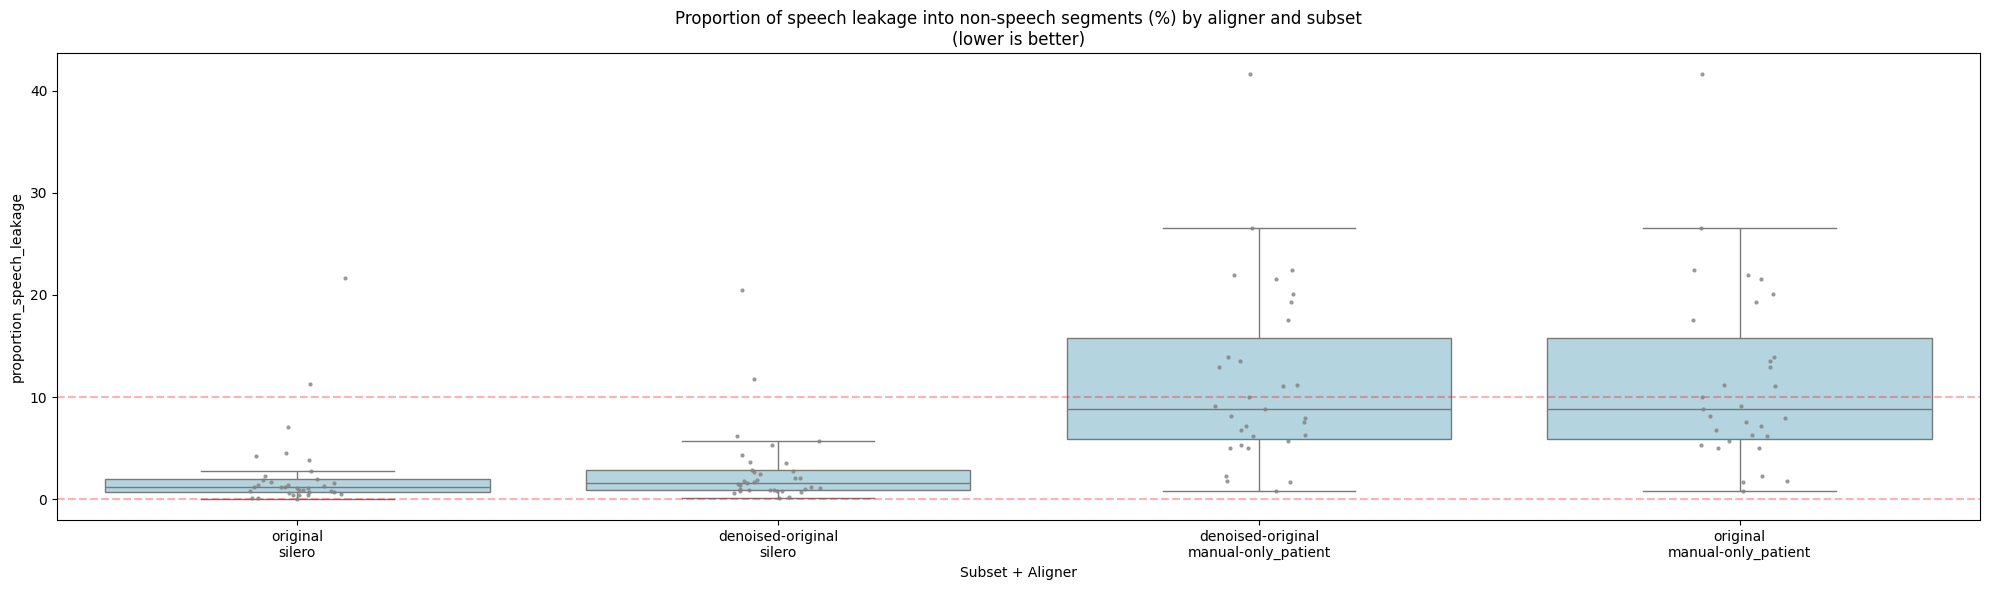

,subset,short_aligner,mean,std
3,original,silero,2.413008,4.057187
1,denoised-original,silero,2.849688,3.846977
0,denoised-original,manual-only_patient,11.594123,8.832575
2,original,manual-only_patient,11.594123,8.832575


In [86]:
print("Speech leakage into non-speech segments (%) — summary (lower is better)")
plot_distribution(mismatch_percentages, 'proportion_speech_leakage', 'Proportion of speech leakage into non-speech segments (%) by aligner and subset\n(lower is better)')

mismatch_percentages.groupby(['subset', 'short_aligner'])['proportion_speech_leakage'].agg(['mean', 'std']).reset_index().sort_values('mean')

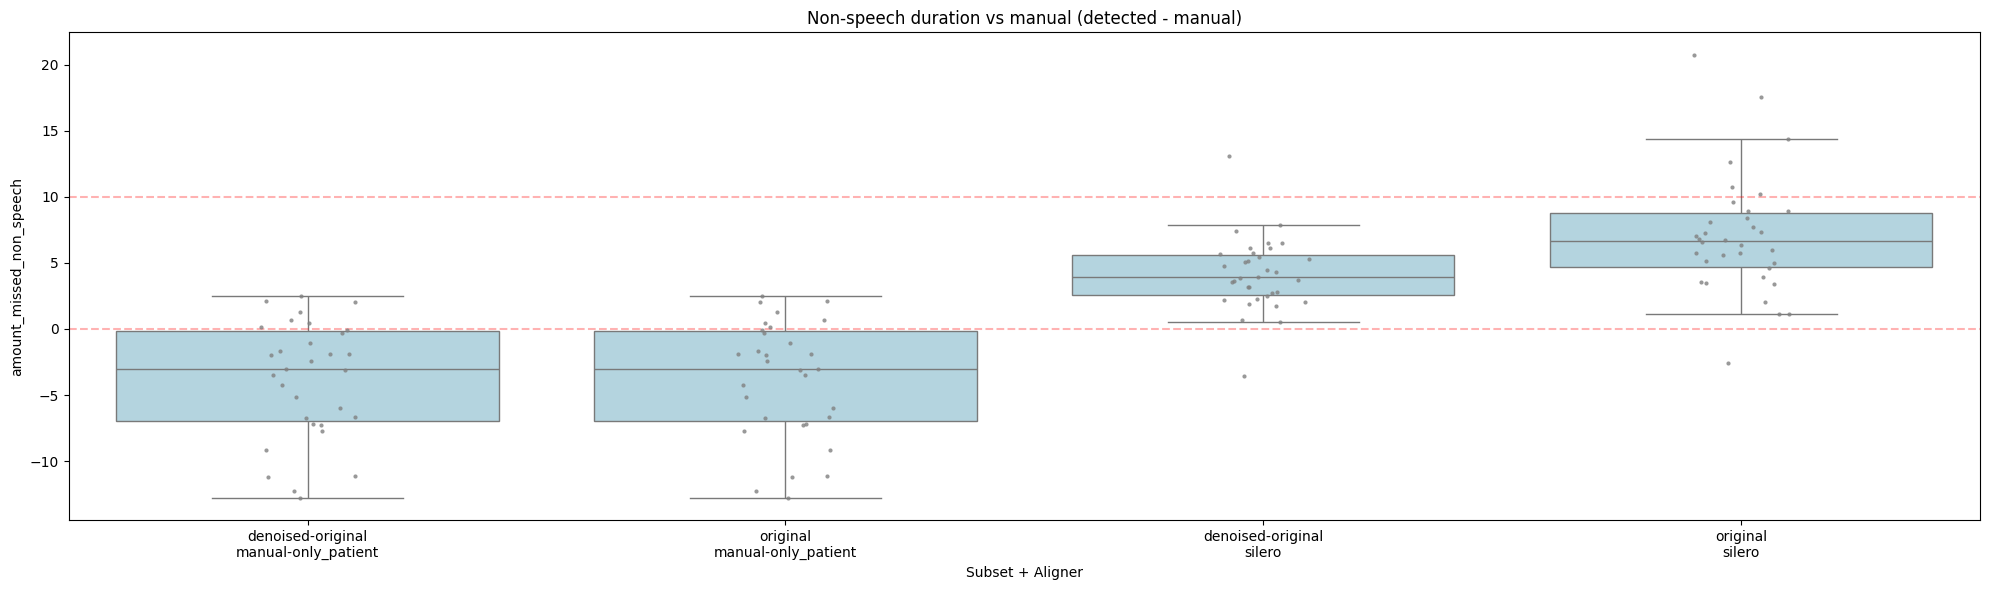

Non-speech duration vs manual (detected - manual) — summary (negative: consider speech as non-speech segments; positive: missed non-speech segments):


,dataset,subset,short_aligner,mean,std
0,chile,denoised-original,manual-only_patient,-3.843226,4.438441
2,chile,original,manual-only_patient,-3.843226,4.438441
1,chile,denoised-original,silero,4.118235,2.753232
3,chile,original,silero,7.060588,4.549066


In [87]:
plot_distribution(mismatch_percentages, 'amount_missed_non_speech', 'Non-speech duration vs manual (detected - manual)')

print("Non-speech duration vs manual (detected - manual) — summary (negative: consider speech as non-speech segments; positive: missed non-speech segments):")
mismatch_percentages.groupby(['dataset', 'subset', 'short_aligner'])['amount_missed_non_speech'].agg(['mean', 'std']).reset_index().sort_values('mean')


In [88]:
speech = '#4C72B0'
no_speech = "#989696"
highlight_color = '#C44E52'

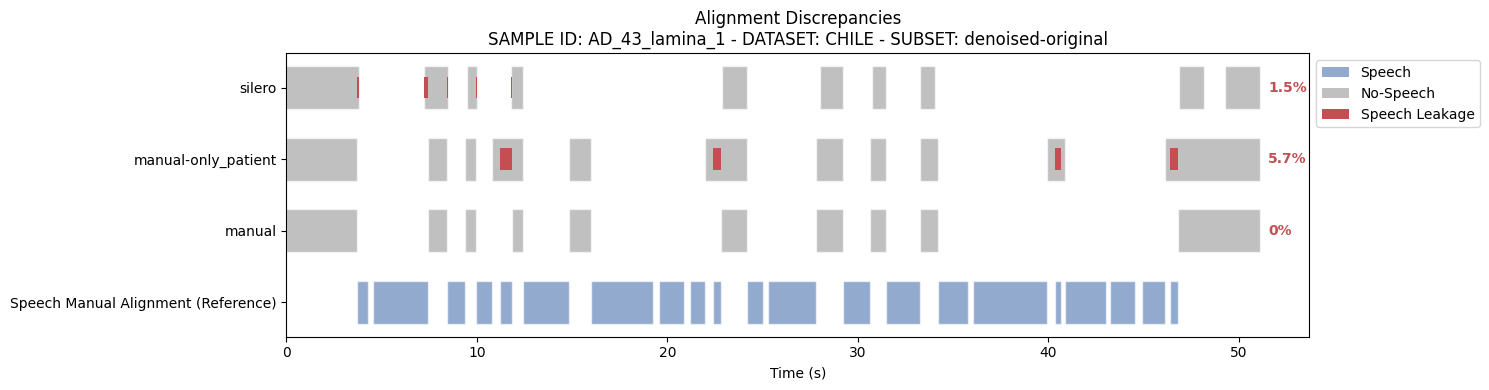

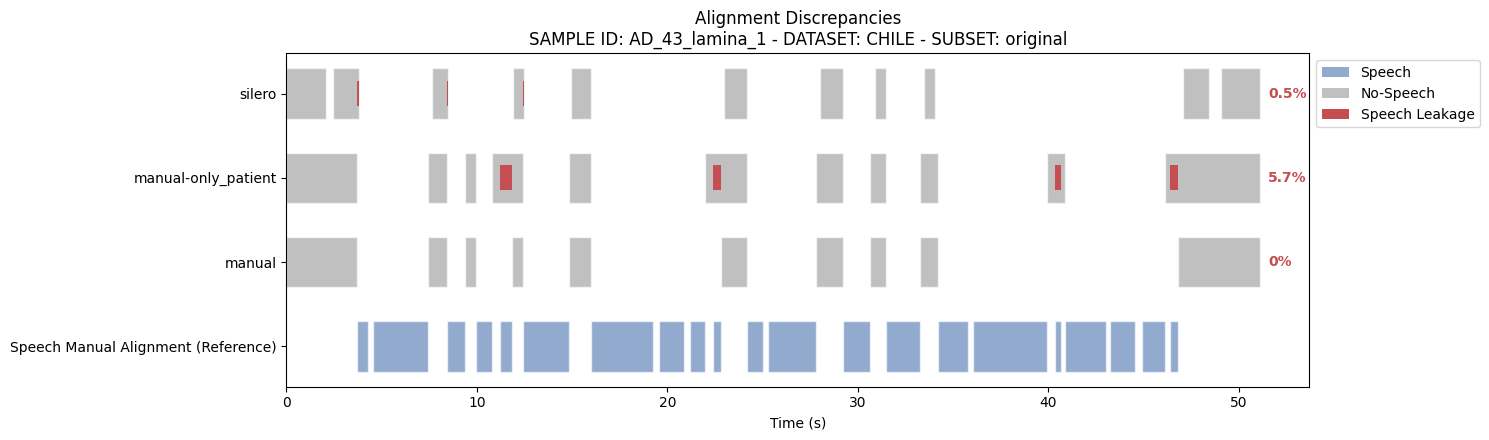

In [89]:
for dataset_name, manual_aligner in manual_per_dataset.items():
    dataset_aligns = aligns[aligns.dataset == dataset_name]
    unique_case = dataset_aligns.sample(1, random_state=28).iloc[0].sample_id
    
    manual_name_for_speech_segments = manual_per_dataset[dataset_name]
    manual_only_speech_case = dataset_aligns[(dataset_aligns.short_aligner == manual_name_for_speech_segments)  & (dataset_aligns.intervals_condition != 'non_speech') & (dataset_aligns.sample_id == unique_case)].drop_duplicates(subset=['start', 'end'], keep='first')
    total_ref_duration = (manual_only_speech_case.end - manual_only_speech_case.start).sum()

    for subset_name, subset_aligns in dataset_aligns.groupby('subset'):
        fig, ax = plt.subplots(figsize=(15, 0.5 * len(subset_aligns.short_aligner.unique()) + 2))
        yticks_locs, yticks_labels = [], []
        
        proportion_pos = subset_aligns[subset_aligns.sample_id == unique_case].end.max() + 0.4
        ax.barh(y=[0]*len(manual_only_speech_case), width=manual_only_speech_case.end - manual_only_speech_case.start, 
                left=manual_only_speech_case.start, height=0.6, color=[speech]*len(manual_only_speech_case), 
                edgecolor='white', alpha=0.6)
        yticks_locs.append(0)
        yticks_labels.append('Speech Manual Alignment (Reference)')
            
        subset = subset_aligns[(subset_aligns.sample_id == unique_case) & (subset_aligns.intervals_condition == 'non_speech')]
        for i, (aligner_name, df_aligner) in enumerate(subset.groupby('short_aligner'), start=1):
            widths = df_aligner.end - df_aligner.start
            
            ax.barh(y=[i]*len(df_aligner), width=widths, left=df_aligner.start, height=0.6, 
                    color=[no_speech]*len(df_aligner), edgecolor='white', alpha=0.6)
            
            mismatch_duration = 0.0
            if aligner_name != manual_name_for_speech_segments:
                for _, sil_row in df_aligner.iterrows():
                    for _, speech_row in manual_only_speech_case.iterrows():
                        start_inter = max(sil_row.start, speech_row.start)
                        end_inter = min(sil_row.end, speech_row.end)
                        if start_inter < end_inter:
                            dur = end_inter - start_inter
                            mismatch_duration += dur
                            ax.barh(y=i, width=end_inter - start_inter, left=start_inter, height=0.3, color=highlight_color, zorder=10)
            
            proportion = (mismatch_duration / total_ref_duration) * 100 if total_ref_duration > 0 else 0
            proportion = int(proportion) if int(proportion) == round(proportion, 1) else round(proportion, 1)
            ax.text(proportion_pos, i, f'{proportion}%', va='center', ha='left', fontweight='bold', color=highlight_color)
            yticks_locs.append(i)
            yticks_labels.append(aligner_name)

        ax.set_yticks(yticks_locs)
        ax.set_yticklabels(yticks_labels)
        ax.set_xlabel('Time (s)')
        ax.set_title(f'Alignment Discrepancies\nSAMPLE ID: {unique_case} - DATASET: {dataset_name.upper()} - SUBSET: {subset_name}')

        legend_elements = [
            Patch(facecolor=speech, label='Speech', alpha=0.6),
            Patch(facecolor=no_speech, label='No-Speech', alpha=0.6),
            Patch(facecolor=highlight_color, label='Speech Leakage')
        ]
        ax.legend(handles=legend_elements, bbox_to_anchor=(1, 1), loc='upper left')

        plt.tight_layout()
        plt.show()